# Codveda Technologies — Level 3, Task 1
## Random Forest for Classification

**Dataset:** Telecom Churn

### Objectives
1. Preprocess the churn dataset
2. Train a Random Forest classifier
3. Tune important hyperparameters using `GridSearchCV`
4. Use cross-validation to select the best model
5. Evaluate the final model using classification metrics
6. Analyze feature importance

### Professional modeling principle
The test set is kept untouched until the final evaluation. Hyperparameters are selected using cross-validation on the training data only.


## 1. Import Required Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 2. Load the Dataset




In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "datasets/churn-bigml-80.csv"

df = pd.read_csv("/content/churn-bigml-80.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())


Dataset loaded successfully.
Rows: 2,666
Columns: 20


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 3. Initial Data Inspection

In [3]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(df["Churn"].value_counts())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0



Duplicate rows:
0

Target distribution:


,count
Churn,
False,2278
True,388


## 4. Remove Duplicate Observations

In [4]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates}")
print(f"New dataset shape: {df.shape}")


Duplicate rows removed: 0
New dataset shape: (2666, 20)


## 5. Define Features and Target

`Churn` is the binary target.

The preprocessing pipeline handles categorical variables with one-hot encoding and numerical variables with median imputation where necessary.


In [5]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

TARGET_COLUMN = "Churn"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)


Categorical features:
['State', 'International plan', 'Voice mail plan']

Numerical features:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


## 6. Train/Test Split

A stratified split keeps the churn class distribution approximately consistent across training and testing data.


In [6]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")


Training set: (2132, 19)
Testing set:  (534, 19)


## 7. Build the Preprocessing Pipeline

Random Forest does **not** require feature scaling because tree splits are based on feature thresholds. Therefore, we encode categorical variables and preserve numerical variables at their original scale.


In [7]:
# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)


## 8. Build the Random Forest Pipeline

In [8]:
# ============================================================
# 8. RANDOM FOREST PIPELINE
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


## 9. Hyperparameter Tuning with Grid Search

The hyperparameters are selected using **5-fold cross-validation** on the training set.

We tune:

- `n_estimators` — number of trees
- `max_depth` — maximum depth of each tree
- `min_samples_split` — minimum samples required to split an internal node
- `min_samples_leaf` — minimum samples required in a leaf

The test set is not used during tuning.


In [9]:
# ============================================================
# 9. GRID SEARCH
# ============================================================

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")


Best hyperparameters:
{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best cross-validation F1 score: 0.7430


## 10. Evaluate the Best Model on the Test Set

In [10]:
# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy : 0.9345
Precision: 0.9778
Recall   : 0.5641
F1 Score : 0.7154

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       456
           1       0.98      0.56      0.72        78

    accuracy                           0.93       534
   macro avg       0.95      0.78      0.84       534
weighted avg       0.94      0.93      0.93       534



## 11. Confusion Matrix

,Predicted No Churn,Predicted Churn
Actual No Churn,455,1
Actual Churn,34,44


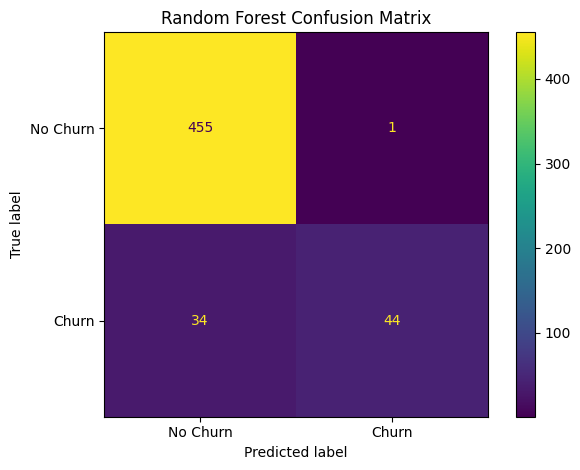

In [11]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

display(
    pd.DataFrame(
        cm,
        index=["Actual No Churn", "Actual Churn"],
        columns=["Predicted No Churn", "Predicted Churn"]
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## 12. Feature Importance

Feature importance measures how much each transformed feature contributes to the Random Forest's impurity reduction.

Because categorical variables are one-hot encoded, individual categories appear as separate features.


In [12]:
# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

fitted_preprocessor = best_model.named_steps["preprocessor"]
rf_classifier = best_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))


,Feature,Importance
0,numerical__Total day minutes,0.133966
1,numerical__Total day charge,0.120521
2,numerical__Customer service calls,0.108865
3,categorical__International plan_No,0.055365
4,numerical__Total eve minutes,0.054231
5,categorical__International plan_Yes,0.052120
6,numerical__Total eve charge,0.047430
7,numerical__Total intl calls,0.043832
8,numerical__Total intl charge,0.041360
9,numerical__Total intl minutes,0.041055


## 13. Visualize the Top 15 Features

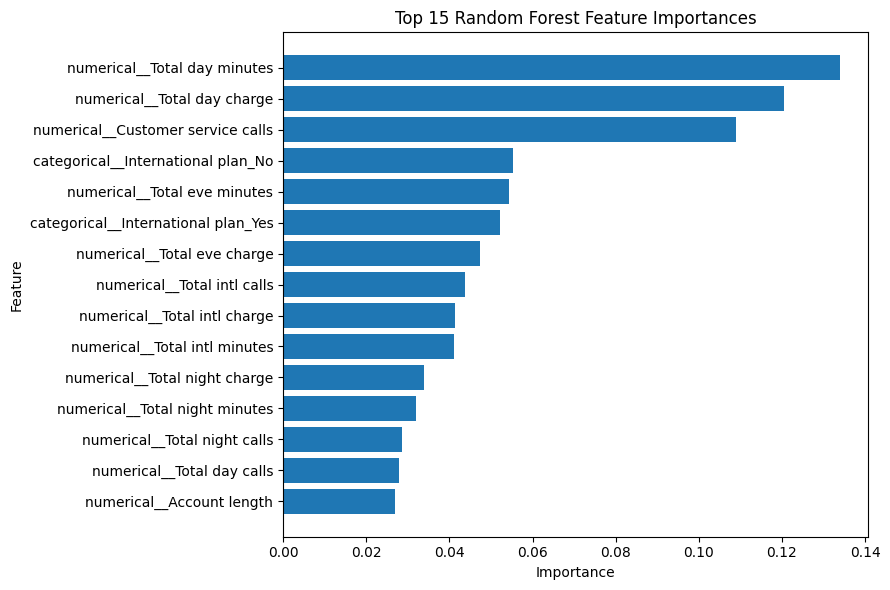

In [13]:
# ============================================================
# 13. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## 14. Final Summary

This task demonstrates:

- Data inspection and cleaning
- Proper train/test separation
- Pipeline-based preprocessing
- Random Forest classification
- Cross-validated hyperparameter tuning
- Final test evaluation
- Classification metrics
- Confusion matrix analysis
- Feature importance analysis

The final test metrics should be reported from the actual execution of the notebook rather than hard-coded.


In [14]:
# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("=" * 65)
print("LEVEL 3 - TASK 1: RANDOM FOREST SUMMARY")
print("=" * 65)

print("Best parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")

print("\nFinal Test Metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1 Score : {f1:.4f}")

print("\nTop 5 features:")
display(importance_df.head(5))

print("=" * 65)


LEVEL 3 - TASK 1: RANDOM FOREST SUMMARY
Best parameters:
  classifier__max_depth: 20
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 5
  classifier__n_estimators: 100

Best CV F1 Score: 0.7430

Final Test Metrics:
  Accuracy : 0.9345
  Precision: 0.9778
  Recall   : 0.5641
  F1 Score : 0.7154

Top 5 features:


,Feature,Importance
0,numerical__Total day minutes,0.133966
1,numerical__Total day charge,0.120521
2,numerical__Customer service calls,0.108865
3,categorical__International plan_No,0.055365
4,numerical__Total eve minutes,0.054231
